In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import torch
import pytorch_lightning.loggers
import rapids_singlecell as rsc
import sc_utils
import gc

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


# Initial clustering

### Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07b_hvg1000_clustered+counts.h5ad')

### Total counts per cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


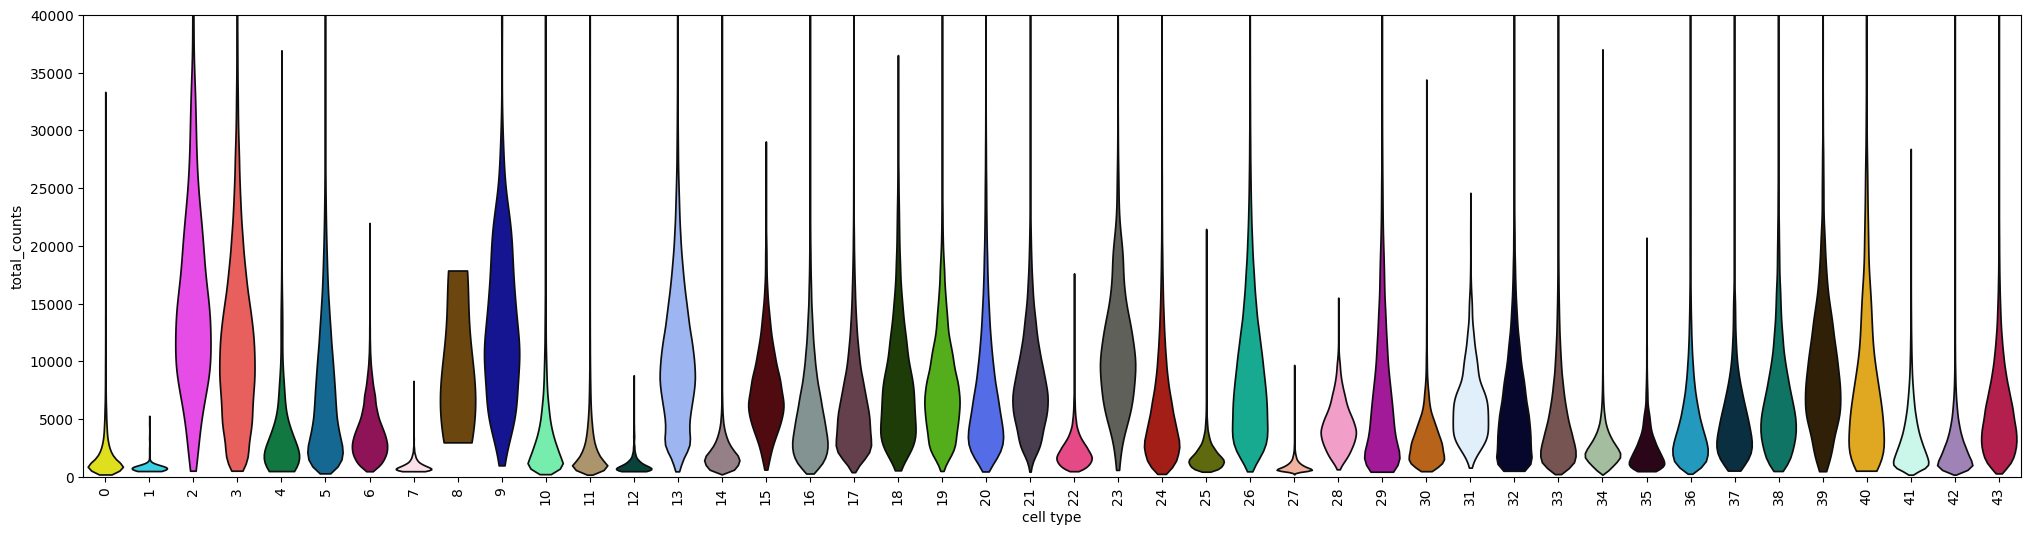

In [4]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "total_counts", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
ax.set_ylim(0, 40000)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Number of expressed genes in a cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


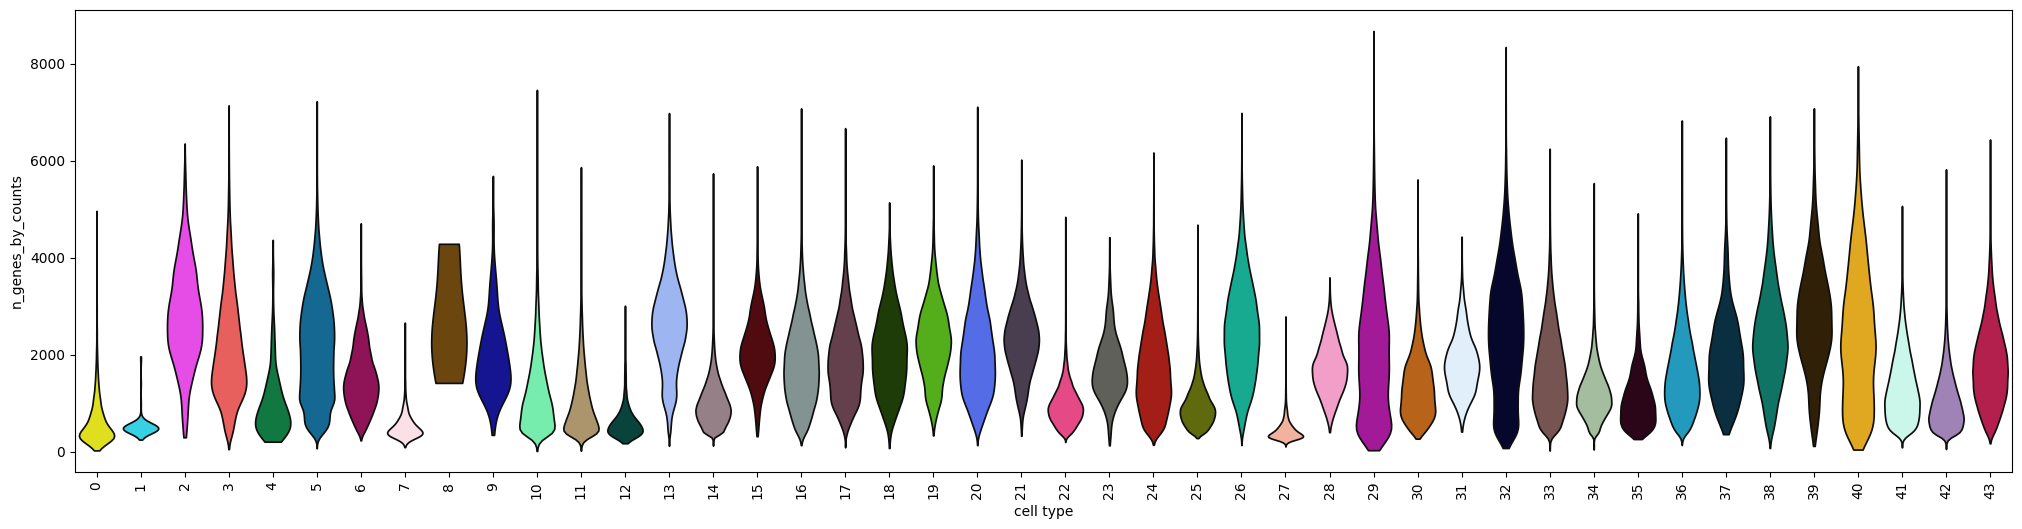

In [5]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "n_genes_by_counts", groupby="cell_type", size=0, ax=ax, show=False)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Percentage of counts in mitochondrial genes

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


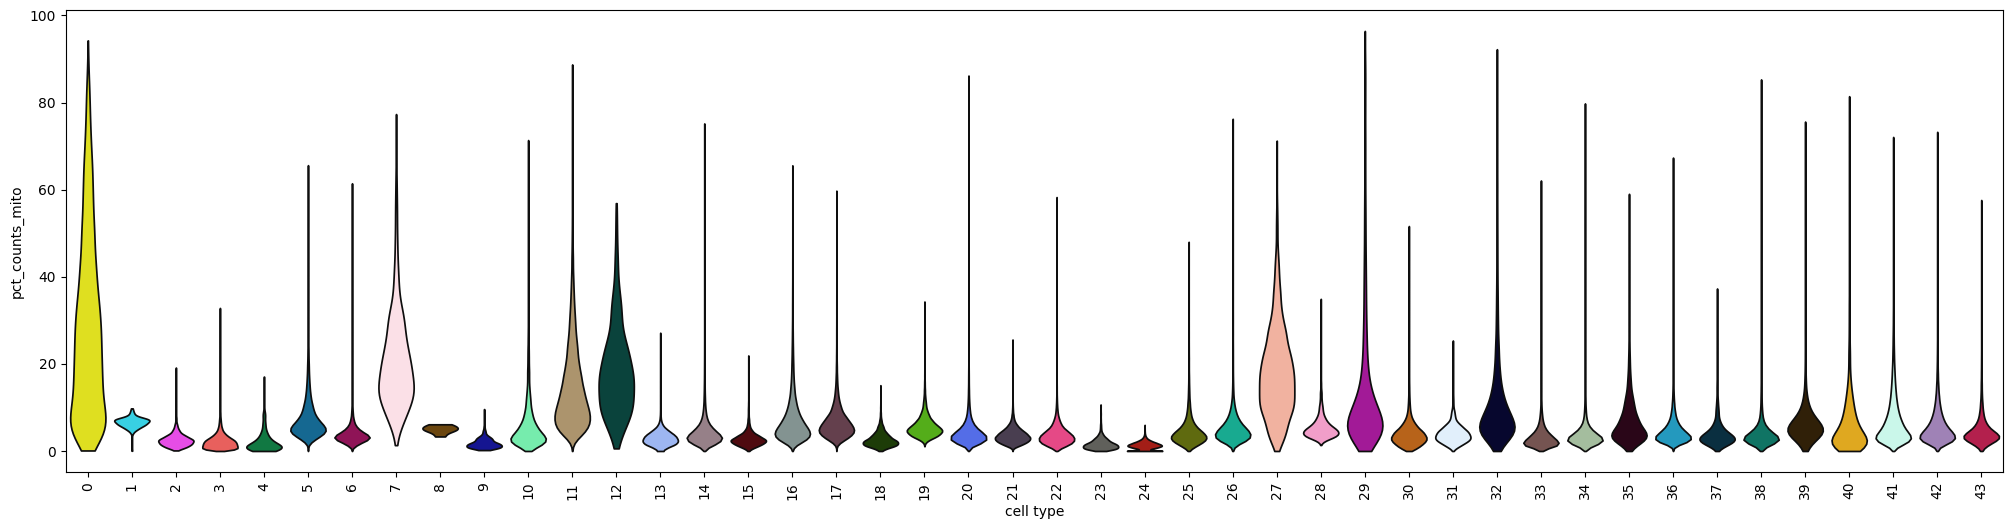

In [7]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


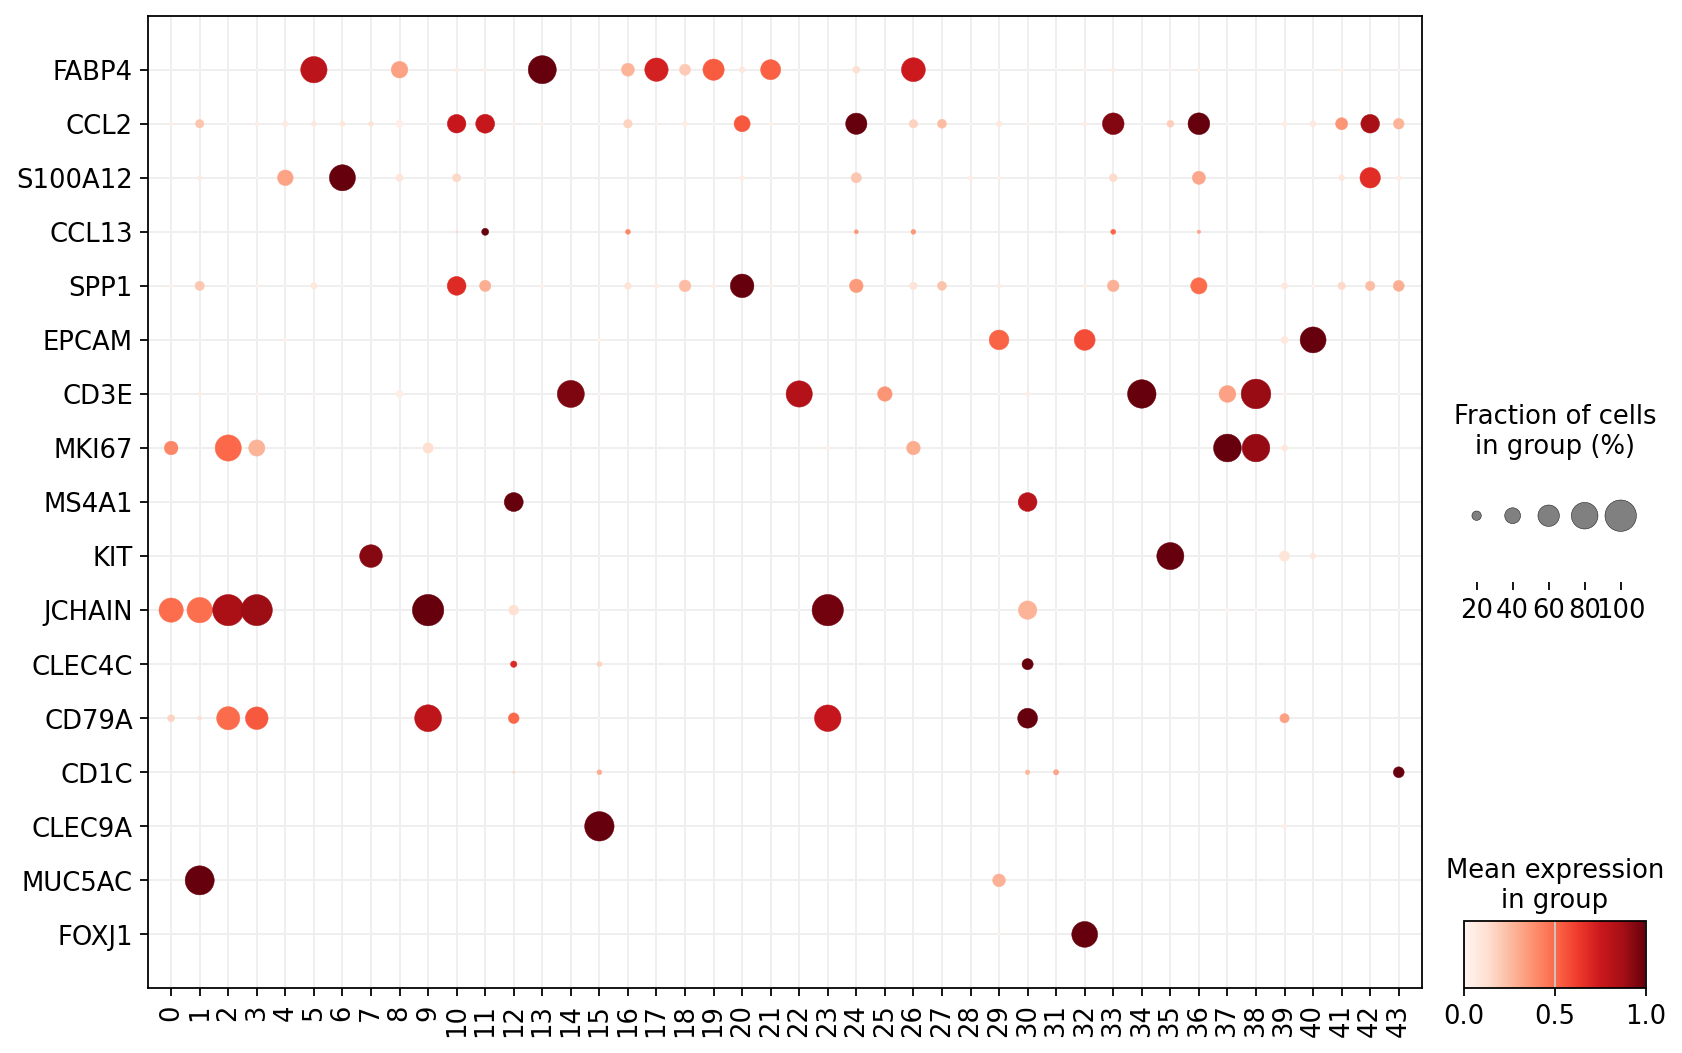

In [25]:
ax = sc.pl.dotplot(
    adata,
    ["FABP4", # TRAM
     "CCL2", # MoAM
     "S100A12", # monocytes
     "CCL13", # perivascular macs
     "SPP1", # profibrotic macs
     "EPCAM", # epithelial
     "CD3E", # T cells
     "MKI67", # proliferating
     "MS4A1", # B cells
     "KIT", # mast
     "JCHAIN", "CLEC4C", # pDC
                "CD79A", # plasma
     "CD1C", # DC2
     "CLEC9A", # DC1,
     "MUC5AC", # Secretory
     "FOXJ1", # ciliated
     ],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

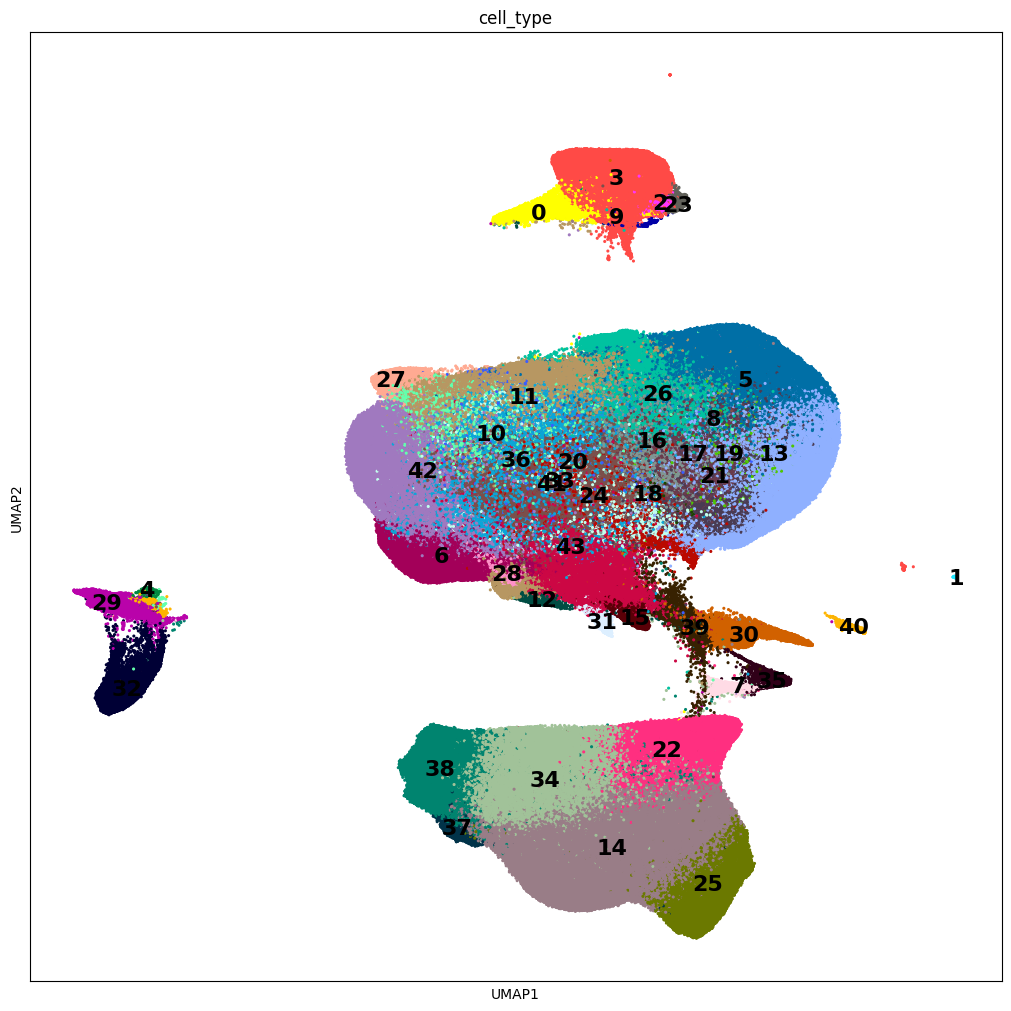

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=20,
    ax=ax,
    show=False,
    legend_fontsize=16
)

### Rank genes with t-test

In [15]:
%%time
sc.tl.rank_genes_groups(adata, "cell_type", method="t-test", n_genes=50)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

CPU times: user 20min 34s, sys: 12min 37s, total: 33min 11s
Wall time: 33min 11s


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

In [16]:
markers = sc_utils.get_markers(adata, "cell_type")

In [17]:
markers.cluster = markers.cluster.astype(int)
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

In [18]:
markers.groupby("cluster").head(5)

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
14,0.0,7.873879,0.664478,0.034829,0.0,0,IGHG1
18,0.0,7.086786,0.529363,0.021693,0.0,0,IGHG3
16,0.0,6.873413,0.615555,0.042307,0.0,0,IGKC
25,0.0,6.767975,0.414686,0.016729,0.0,0,IGHG4
22,0.0,6.607876,0.527051,0.032214,0.0,0,IGHA1
...,...,...,...,...,...,...,...
2190,0.0,3.960571,0.337797,0.032067,0.0,43,CLEC10A
2171,0.0,3.041169,0.482430,0.090170,0.0,43,GPR183
2153,0.0,2.913934,0.973373,0.635986,0.0,43,HLA-DPB1
2158,0.0,2.901068,0.834623,0.384504,0.0,43,HLA-DQA1


### Save

In [ ]:
adata.write_h5ad(common_data._sc_root / '07c_1000_10.h5ad')

In [ ]:
markers.to_csv(common_data._sc_root / "07c_1000_10-markers.csv")

### Generate cluster tree
Pearson correlation plot between clusters using log normalized gene expression data from PCA representation

In [21]:
sc.tl.dendrogram(adata, 'cell_type', cor_method='pearson')

         Falling back to preprocessing with `sc.pp.pca` and default params.


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


<Axes: >

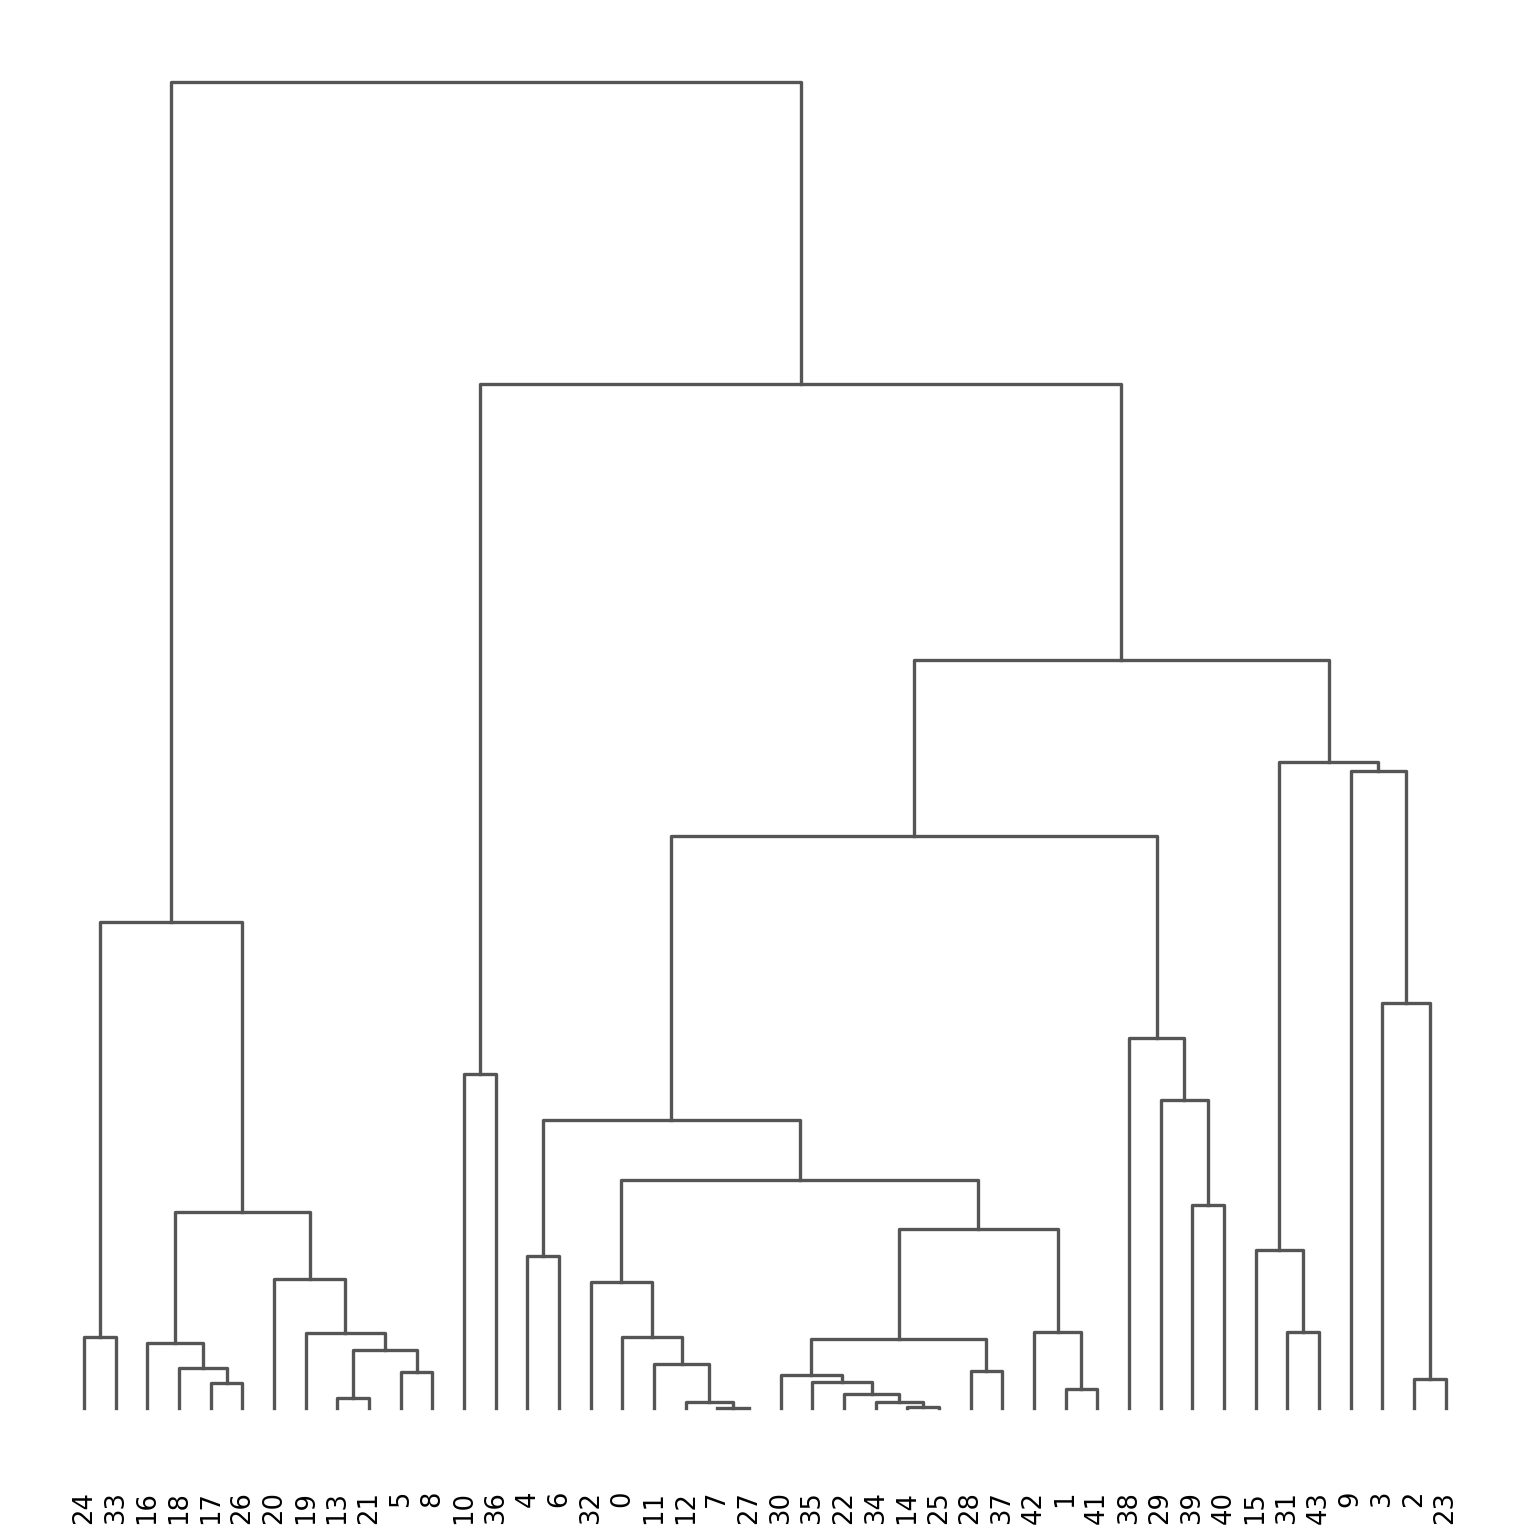

In [22]:
sc.set_figure_params(figsize=(12, 12))
sc.pl.dendrogram(adata, groupby='cell_type', show=False)

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07c_1000_10.h5ad')

### Check which of these genes made HVG selection

In [32]:
# specify the prefix pattern
prefixes_to_remove = ['AC', 'AL', 'AP', 'AF', 'AD', 'BX', 'CR', 'FP', 'KF']

# specify tlhe pattern to match genes to remove
pattern_to_remove = '|'.join([f'{prefix}\d{{6}}\.\d' for prefix in prefixes_to_remove] + ['Z\d{5}\.\d', 'U\d{5}\.\d'])

mask = adata.raw.var.index.str.contains(pattern_to_remove, regex=True)

In [41]:
ribo_mask = adata.raw.var.index.str.startswith(("RPS", "RPL"))

In [42]:
mask.sum()

5549

In [43]:
ribo_mask.sum()

104

In [34]:
matching_genes = adata.raw.var.index[mask]

In [36]:
matching_genes

Index(['AL627309.1', 'AL627309.3', 'AL669831.5', 'AL645608.7', 'AL645608.3',
       'AL645608.1', 'AL645608.8', 'AL645608.2', 'AL645608.9', 'AL390719.2',
       ...
       'AL592183.1', 'AC007325.1', 'AC007325.4', 'AC007325.2', 'AL354822.1',
       'AC023491.2', 'AC004556.1', 'AC233755.2', 'AC233755.1', 'AC240274.1'],
      dtype='object', length=5549)

In [40]:
adata.var_names[adata.var_names.isin(matching_genes)]

Index(['AC006369.1', 'AC013457.1', 'AC013264.1', 'AC093010.2', 'AC136475.3',
       'AL357093.2', 'AC020659.1', 'AC007906.2', 'AC005224.3', 'AC007952.4',
       'AC103702.2', 'AC015912.3', 'AP005482.1', 'Z82206.1', 'AF165147.1',
       'AC233755.1'],
      dtype='object')

In [44]:
adata.var_names[adata.var_names.isin(adata.raw.var.index[ribo_mask])]

Index(['RPL11', 'RPS8', 'RPS27', 'RPS7', 'RPS27A', 'RPL32', 'RPSA', 'RPL14',
       'RPL29', 'RPL34', 'RPS3A', 'RPS23', 'RPS14', 'RPS18', 'RPS12', 'RPS4X',
       'RPL39', 'RPL10', 'RPL30', 'RPL8', 'RPS6', 'RPL12', 'RPL7A', 'RPS13',
       'RPS3', 'RPS24', 'RPS26', 'RPL41', 'RPLP0', 'RPLP1', 'RPS2', 'RPS15A',
       'RPL13', 'RPL19', 'RPS15', 'RPS28', 'RPL18A', 'RPS19', 'RPL18', 'RPL28',
       'RPS5', 'RPL3'],
      dtype='object')

### Plot dot plot

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


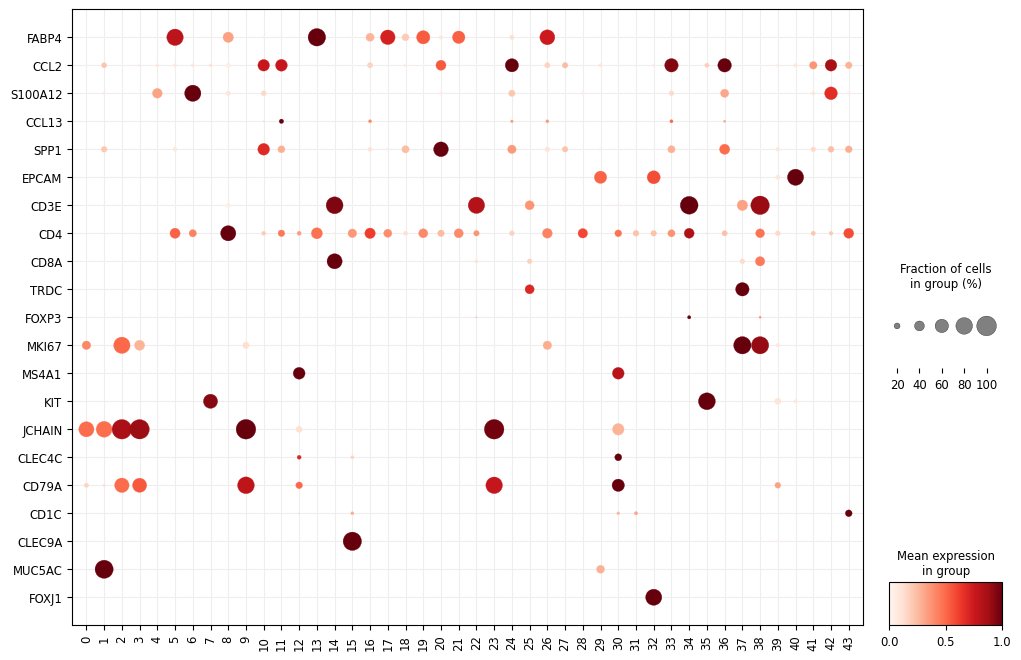

In [3]:
ax = sc.pl.dotplot(
    adata,
    ["FABP4", # TRAM
     "CCL2", # MoAM
     "S100A12", # monocytes
     "CCL13", # perivascular macs
     "SPP1", # profibrotic macs
     "EPCAM", # epithelial
     "CD3E", # T cells
     "CD4", "CD8A", "TRDC", "FOXP3",
     "MKI67", # proliferating
     "MS4A1", # B cells
     "KIT", # mast
     "JCHAIN", "CLEC4C", # pDC
                "CD79A", # plasma
     "CD1C", # DC2
     "CLEC9A", # DC1,
     "MUC5AC", # Secretory
     "FOXJ1", # ciliated
     ],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

### gdT cells

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


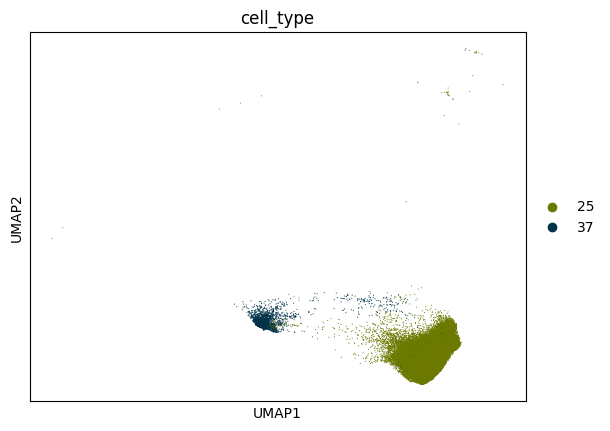

In [4]:
sc.pl.umap(adata[adata.obs.cell_type.isin(['25','37'])], color="cell_type")

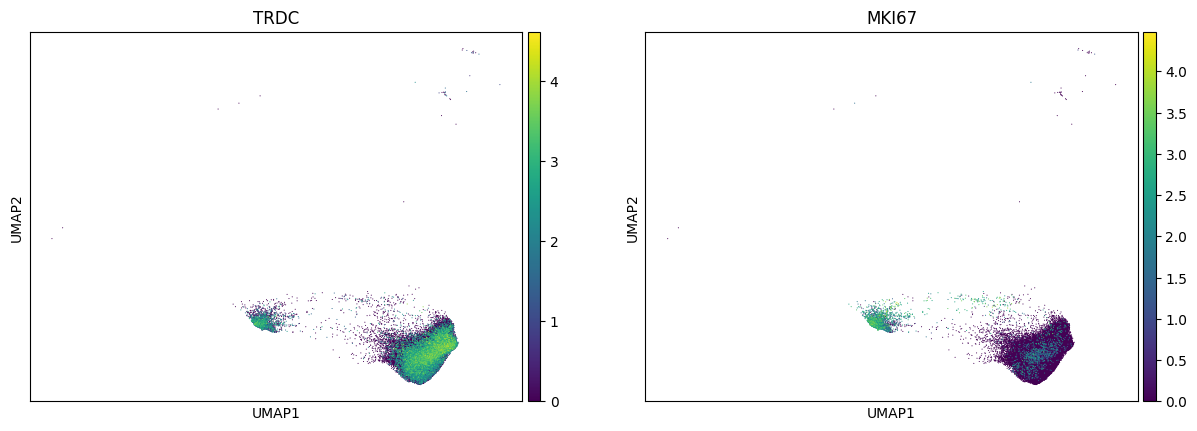

In [5]:
sc.pl.umap(adata[adata.obs.cell_type.isin(['25','37'])], color=["TRDC", "MKI67"])

25 - gdT cells

37 - proliferating gdT cells

### Tregs

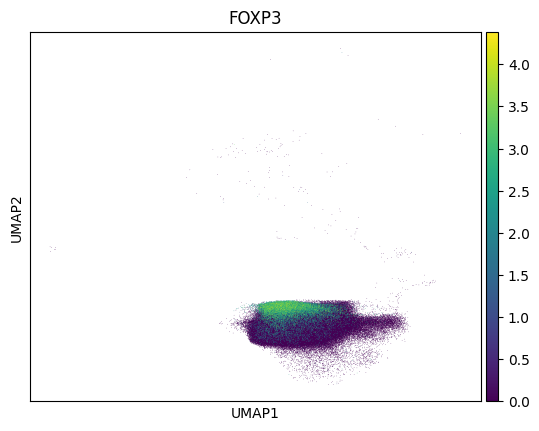

In [6]:
sc.pl.umap(adata[adata.obs.cell_type.isin(['34'])], color=["FOXP3"])

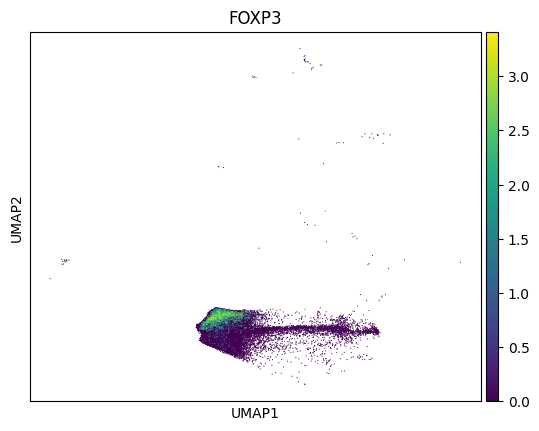

In [7]:
sc.pl.umap(adata[adata.obs.cell_type.isin(['38'])], color=["FOXP3"])

## Resolve Tregs within clusters 34 & 38
### Cluster 34

In [3]:
cluster34 = adata[adata.obs.cell_type == "34"]

In [4]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster34, use_rep="X_scVI")
rsc.tl.umap(cluster34, min_dist=0.3)

In [5]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster34, key_added="cell_type", resolution=0.2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

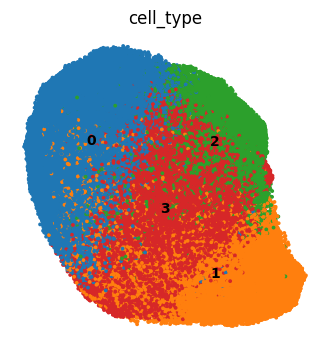

In [6]:
mpl.rcParams["figure.figsize"] = (4, 4)

sc.pl.umap(
    cluster34,
    color=["cell_type"],
    frameon=False, legend_loc="on data", show=False, size=30)

<Axes: title={'center': 'FOXP3'}, xlabel='UMAP1', ylabel='UMAP2'>

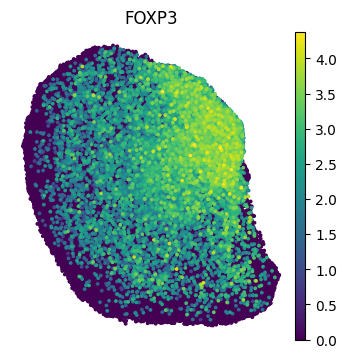

In [7]:
mpl.rcParams["figure.figsize"] = (4, 4)

sc.pl.umap(
    cluster34,
    color=["FOXP3"],
    frameon=False, legend_loc="on data", show=False, size=30)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


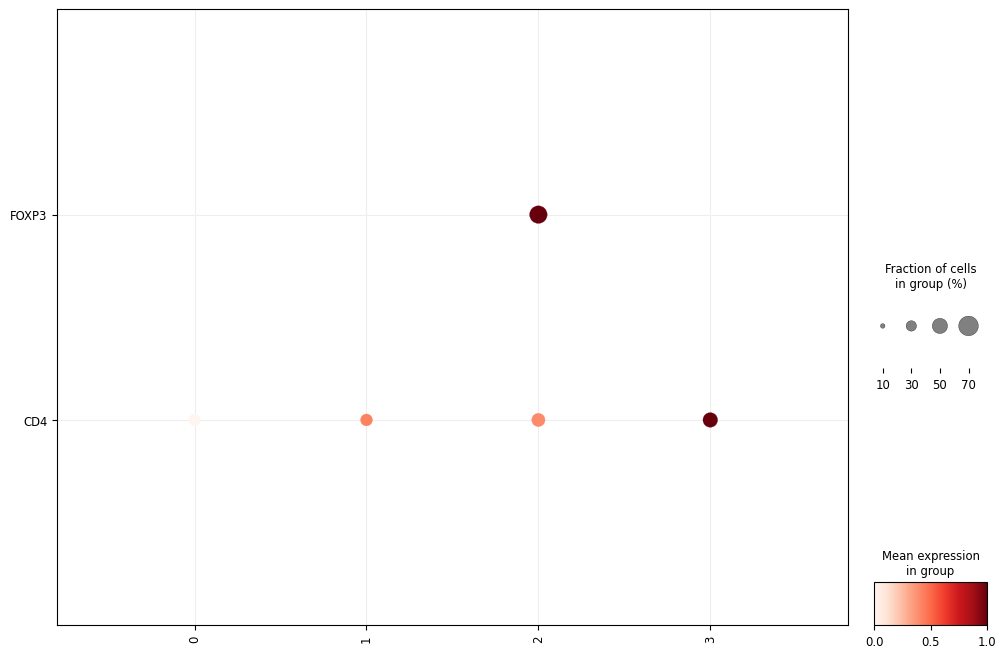

In [8]:
ax = sc.pl.dotplot(
    cluster34,
    ["FOXP3", "CD4"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

### Rename subclusters

In [16]:
cluster34.obs.cell_type.replace({
    "0": "CD4 T cells",
    "1": "CD4 T cells",
    "2": "Tregs",
    "3": "CD4 T cells",
}, inplace=True)

### Cluster 38

In [9]:
cluster38 = adata[adata.obs.cell_type == "38"]

In [10]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster38, use_rep="X_scVI")
rsc.tl.umap(cluster38, min_dist=0.3)

In [11]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster38, key_added="cell_type", resolution=0.3)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

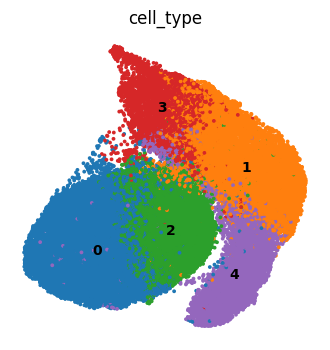

In [12]:
mpl.rcParams["figure.figsize"] = (4, 4)

sc.pl.umap(
    cluster38,
    color=["cell_type"],
    frameon=False, legend_loc="on data", show=False, size=30)

<Axes: title={'center': 'FOXP3'}, xlabel='UMAP1', ylabel='UMAP2'>

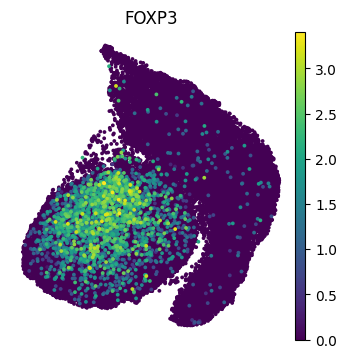

In [13]:
mpl.rcParams["figure.figsize"] = (4, 4)

sc.pl.umap(
    cluster38,
    color=["FOXP3"],
    frameon=False, legend_loc="on data", show=False, size=30)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


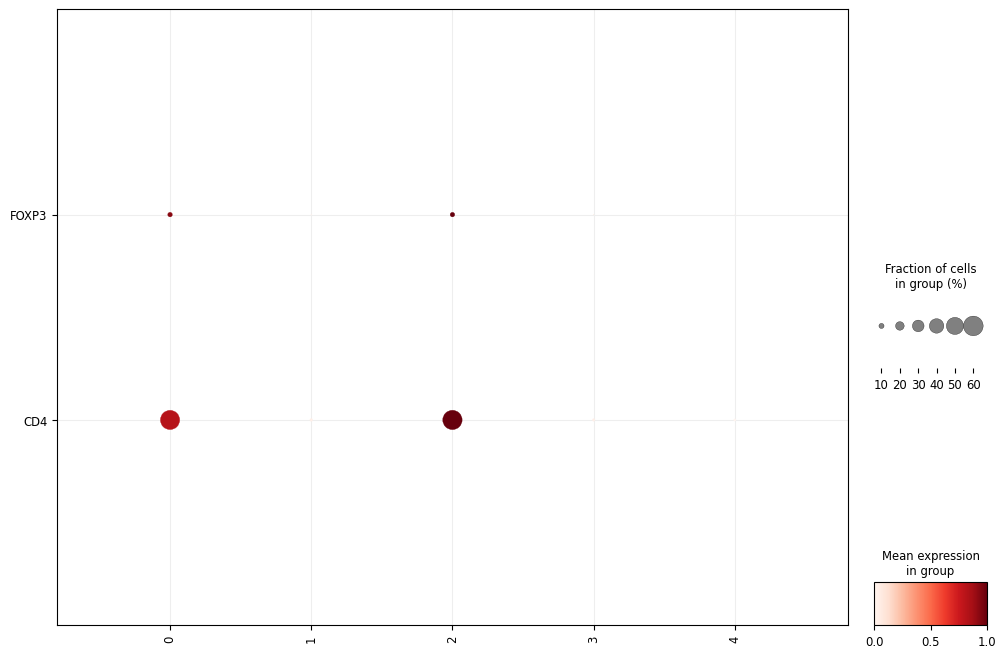

In [14]:
ax = sc.pl.dotplot(
    cluster38,
    ["FOXP3", "CD4"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [19]:
df = pd.DataFrame(cluster38.obs[cluster38.obs.cell_type.isin(['0','2'])].index, columns=["Index"])

In [22]:
df.to_csv('cluster38_tregs_filtered.csv', index=False)

### Rename subclusters

In [23]:
cluster38.obs.cell_type.replace({
    "0": "Tregs",
    "1": "CD4 T cells",
    "2": "Tregs",
    "3": "CD4 T cells",
    "4": "CD4 T cells",
}, inplace=True)

### Resolve cluster 30 - B cells, pDC

In [24]:
cluster30 = adata[adata.obs.cell_type == "30"]

In [25]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cluster30, use_rep="X_scVI")
rsc.tl.umap(cluster30, min_dist=0.3)

In [26]:
# neighbors were already computed using scVI
rsc.tl.leiden(cluster30, key_added="cell_type", resolution=0.2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

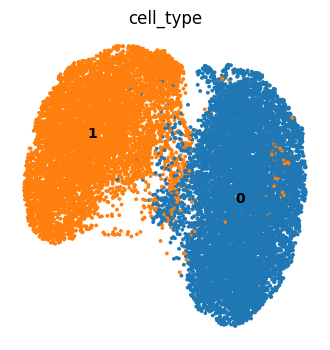

In [27]:
mpl.rcParams["figure.figsize"] = (4, 4)

sc.pl.umap(
    cluster30,
    color=["cell_type"],
    frameon=False, legend_loc="on data", show=False, size=30)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


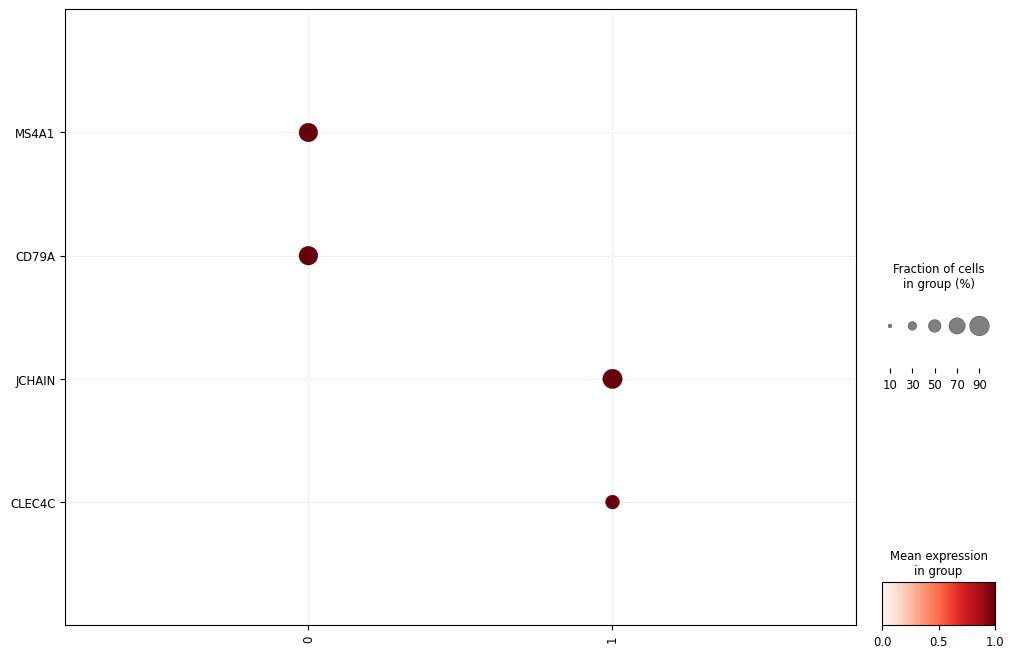

In [28]:
ax = sc.pl.dotplot(
    cluster30,
    ["MS4A1","CD79A", "JCHAIN","CLEC4C"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

### Rename subclusters

In [29]:
cluster30.obs.cell_type.replace({
    "0": "B cells",
    "1": "pDC",
}, inplace=True)

## Remove cluster 0 - low quality

In [30]:
adata = adata[~adata.obs.cell_type.isin(['0'])]

In [31]:
adata.shape

(2480619, 1000)

### Add subclusters into large adata object

In [32]:
adata.obs.cell_type = adata.obs.cell_type.astype("str")

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/pandas/core/generic.py:5931: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value


In [33]:
adata.obs.loc[cluster34.obs_names, "cell_type"] = cluster34.obs.cell_type

In [34]:
adata.obs.loc[cluster38.obs_names, "cell_type"] = cluster38.obs.cell_type

In [35]:
adata.obs.loc[cluster30.obs_names, "cell_type"] = cluster30.obs.cell_type

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


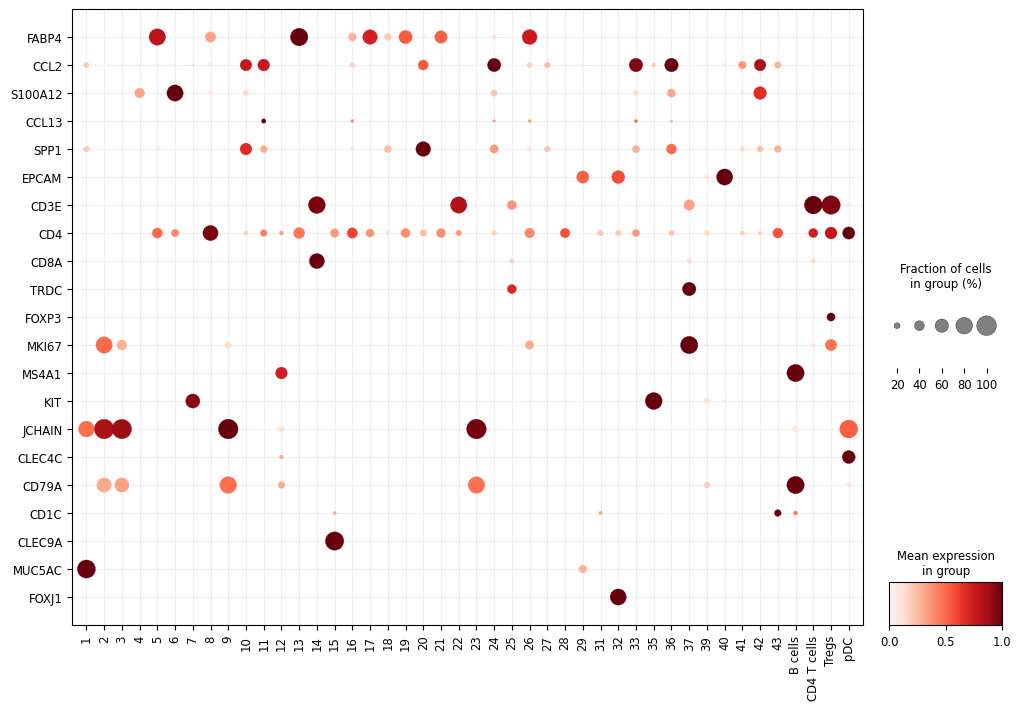

In [36]:
ax = sc.pl.dotplot(
    adata,
    ["FABP4", # TRAM
     "CCL2", # MoAM
     "S100A12", # monocytes
     "CCL13", # perivascular macs
     "SPP1", # profibrotic macs
     "EPCAM", # epithelial
     "CD3E", # T cells
     "CD4", "CD8A", "TRDC", "FOXP3",
     "MKI67", # proliferating
     "MS4A1", # B cells
     "KIT", # mast
     "JCHAIN", "CLEC4C", # pDC
                "CD79A", # plasma
     "CD1C", # DC2
     "CLEC9A", # DC1,
     "MUC5AC", # Secretory
     "FOXJ1", # ciliated
     ],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

## Rename rest of clusters

In [37]:
adata.obs.cell_type.replace({
    "1": "Secretory cells",
    "2": "Proliferating plasma cells",
    "3": "Proliferating plasma cells",
    "4": "Epithelial, squamous",
    "6": "Monocytes",
    "7": "Mast cells",
    "9": "Plasma cells",
    "12": "B cells",
    "14": "CD8 T cells",
    "15": "DC1",
    "22": "CD4 T cells",
    "23": "Plasma cells",
    "25": "gdT cells",
    "28": "Monocytes",
    "29": "Secretory cells",
    "31": "Migratory DC",
    "32": "Ciliated cells",
    "35": "Mast cells",
    "37": "Proliferating gdT cells",
    "40": "Epithelial cells",
    "43": "DC2"
}, inplace=True)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

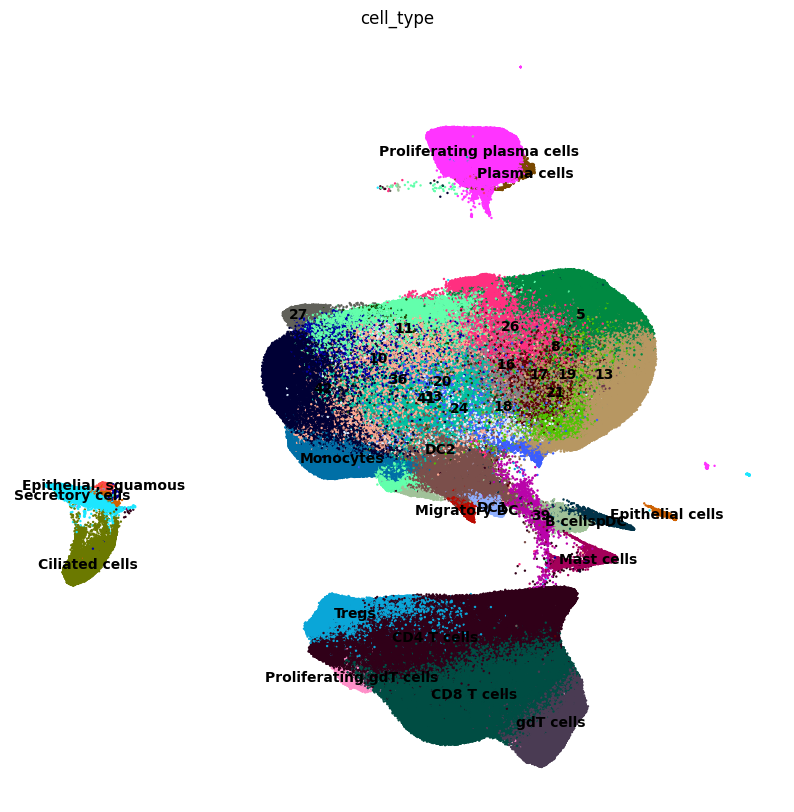

In [38]:
mpl.rcParams["figure.figsize"] = (10, 10)

sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False, legend_loc="on data", show=False, size=12)

### Save

In [ ]:
adata.write_h5ad(common_data._sc_root / '07c_1000_10-1/07c_1000_10-1.h5ad')

In [ ]:
adata.obs.to_csv(common_data._sc_root / '07c_1000_10-1-metadata.csv')

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07c_1000_10-1/07c_1000_10-1.h5ad')

# Filter out genes from our count matrix
Many models require specific preprocessing & this may speed up cellbrowser loading + pushing to pulm-data.


In [3]:
adata.shape

(2480619, 1000)

In [4]:
adata.raw.shape

(2480619, 25141)

### Remove transcripts with 'AC', 'AP', 'AL', 'AF', etc. prefix from list of genes. Also remove ribosomal genes.
These are "genes" are actually transcripts with prefixes like ACXXXXX, APXXXXXX, and ALXXXXXX. See Biostars note [here](https://www.biostars.org/p/9553891/). Since these are not biologically significant genes, it makes sense to exclude them. However, we don't expect to find them expressed since they are uniquely detected in 3' chemistry.

Ribosomal genes are being filtered here as they may need to be removed for model specific preprocessing for downstream analysis.

In [5]:
# specify the prefix pattern
prefixes_to_remove = ['AC', 'AL', 'AP', 'AF', 'AD', 'BX', 'CR', 'FP', 'KF']

# specify tlhe pattern to match genes to remove
pattern_to_remove = '|'.join([f'{prefix}\d{{6}}\.\d' for prefix in prefixes_to_remove] + ['Z\d{5}\.\d', 'U\d{5}\.\d'])

In [6]:
# Create boolean masks for both conditions
pattern_mask = adata.raw.var.index.str.contains(pattern_to_remove, regex=True)
ribo_mask = adata.raw.var.index.str.startswith(("RPS", "RPL"))

# Create a combined mask using numpy.logical_or
combined_mask = np.logical_or(pattern_mask, ribo_mask)

In [7]:
print(pattern_mask.sum())
print(ribo_mask.sum())
print(combined_mask.sum())

5549
104
5653


In [8]:
import anndata
# Create a new AnnData object with the filtered data
filtered_adata = anndata.AnnData(
    X=adata.raw.X[:, ~combined_mask],
    obs=adata.obs,
    var=adata.raw.var[~combined_mask],
)

# Update the original adata.raw with the filtered AnnData
adata.raw = filtered_adata

In [9]:
adata.shape

(2480619, 1000)

In [10]:
adata.raw.shape

(2480619, 19488)

In [11]:
del filtered_adata

### Save

In [ ]:
adata.write_h5ad(common_data._sc_root / '07c_1000_10-2.h5ad')

### Find markers with t-test

In [13]:
%%time
sc.tl.rank_genes_groups(adata, "cell_type", method="t-test", n_genes=50)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

CPU times: user 21min 34s, sys: 15min 26s, total: 37min
Wall time: 37min 1s


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:422: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataF

In [14]:
markers = sc_utils.get_markers(adata, "cell_type")

In [15]:
# markers.cluster = markers.cluster.astype(int)
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

In [16]:
markers.groupby("cluster").head(5)

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
428,0.0,3.784136,0.369439,0.109719,0.0,10,HSPA1B
413,0.0,3.671674,0.469766,0.080965,0.0,10,CXCL8
403,0.0,3.370562,0.757666,0.303921,0.0,10,SOD2
414,0.0,3.264267,0.503318,0.146931,0.0,10,SPP1
440,0.0,3.213386,0.323860,0.062322,0.0,10,G0S2
...,...,...,...,...,...,...,...
1841,0.0,11.849991,0.619298,0.000440,0.0,pDC,SCT
1846,0.0,11.609035,0.575169,0.000429,0.0,pDC,CLEC4C
1809,0.0,9.940525,0.784750,0.004387,0.0,pDC,LILRA4
1805,0.0,9.051080,0.865452,0.011177,0.0,pDC,PLD4


### Save

In [ ]:
adata.write_h5ad(common_data._sc_root / '07c_1000_10-2/07c_1000_10-2.h5ad')

In [ ]:
markers.to_csv(common_data._sc_root / '07c_1000_10-2/07c_1000_10-2-markers.csv')

In [ ]:
adata.obs.to_csv(common_data._sc_root / '07c_1000_10-2/07c_1000_10-2-metadata.csv')